# STA 141A: Predicting Wildfire Incidence in the United States
## Hoang Trang Thy Trinh ##


## Overview

The goal of this final project is to develop a prediction model for the incidence and location of notable wildfires in the United States ([link](https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires/data)). You will use historical wildfire records to estimate the probability that a wildfire will occur in a given geographic area during a future month.

A full modeling pipeline is expected, including:
- Careful problem formulation and data preprocessing  
- Exploratory analysis to motivate modeling choices  
- Predictive modeling with appropriate validation  
- Clear interpretation and communication of results  

Students are expected to submit a final written report, organized according to the sections described below. Each student is expected to write their own reproducible report, but discussion is encouraged. 



---


## Data and background

You can find and download a subset of historical wildfire records derived from the Kaggle dataset *“188 Million US Wildfires”*. The dataset includes wildfire ignition locations, discovery dates, containment dates, and final burned area across the contiguous United States. You are encouraged, but not required, to use the full dataset from the original source. 

Wildfires vary widely in size, and the vast majority of recorded fires are very small and quickly contained. Modeling all recorded fires would lead to extreme class imbalance and would obscure the dynamics of fires that are operationally and scientifically meaningful.

To address this, you may filter the raw wildfire records to retain only “notable” fires. A recommended cutoff is to retain only the wildfires with final burned area $\geq$ 300 acres.  This threshold is consistent with operational wildfire reporting standards used by U.S. fire management agencies, where *large wildland fires* are commonly defined as: $\geq$ 100 acres in timber fuel models, or  $\geq$ 300 acres in grass or brush fuel models  

**Alternative Cutoffs.** You may choose an alternative cutoff  if you clearly justify your choice. Any alternative cutoff must be clearly justified in writing and applied consistently throughout the project.  



WHAT TO DO:
1) Filter the data set so what is left is wildfires with final burned area >= 300 acres. (use FIRE_SIZE)

2) Hi Hello

---

## Prediction Task

The prediction task is formulated as a binary classification problem with spatial and temporal structure.

- **Outcome**  
  For each spatial unit and month, define a binary variable indicating whether at least one notable wildfire occurs during that month.

  **WHAT TO DO: did wildfire occur that month YES NO problem.**

- **Spatial unit**  
  You may choose an appropriate spatial unit (e.g., grid cells, counties, or other geographic partitions). The choice should balance spatial resolution, interpretability, and data sparsity. 

- **Temporal unit**  
  Month. You may refine your resolution to week or day with clear justification. 

- **Predictors**  
  You may select any variables in the dataset as your predictors. External data sources (e.g., weather or land cover) are allowed but not required.

---

## Report Structure and Required Sections

Your final report must contain an **abstract** and the following **five** sections. 
Each section should combine clear explanation, appropriate visual or tabular outputs, and interpretation. 

You may add an optional Introduction or Background section to improve the exposition of the report. 


### 1. Data Preprocessing

This section should clearly explain how the raw wildfire data are transformed into the final dataset used for modeling.

The report should explain
- How notable fires are identified and filtered  
- How space–time units are constructed (e.g., grid-by-month)  
- How the binary outcome variable is defined  
- How predictors are constructed or aggregated  
- How missing data or edge cases are handled  

**Minimum required output:** A summary table describing the final dataset used for predictive modeling. 

In [3]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(tidyverse)
    library(pROC)
    library(Matrix)
})

In [15]:
wildfires <-read.csv(file = "/Users/thytrinh/Desktop/STA141AW26/Data/wildfires_sample_100k.csv")
#head(wildfires)
glimpse(wildfires)

Rows: 100,000
Columns: 39
$ OBJECTID                   <int> 16, 68, 73, 111, 191, 228, 264, 269, 294, 3…
$ FOD_ID                     <int> 16, 68, 74, 112, 194, 231, 268, 274, 299, 3…
$ FPA_ID                     <chr> "FS-1418876", "FS-1419017", "FS-1419045", "…
$ SOURCE_SYSTEM_TYPE         <chr> "FED", "FED", "FED", "FED", "FED", "FED", "…
$ SOURCE_SYSTEM              <chr> "FS-FIRESTAT", "FS-FIRESTAT", "FS-FIRESTAT"…
$ NWCG_REPORTING_AGENCY      <chr> "FS", "FS", "FS", "FS", "FS", "FS", "FS", "…
$ NWCG_REPORTING_UNIT_ID     <chr> "USCAENF", "USMTKNF", "USMTKNF", "USCASNF",…
$ NWCG_REPORTING_UNIT_NAME   <chr> "Eldorado National Forest", "Kootenai Natio…
$ SOURCE_REPORTING_UNIT      <chr> "0503", "0114", "0114", "0515", "0302", "03…
$ SOURCE_REPORTING_UNIT_NAME <chr> "Eldorado National Forest", "Kootenai Natio…
$ LOCAL_FIRE_REPORT_ID       <chr> "103", "43", "33", "2", "279", "16", "37", …
$ LOCAL_INCIDENT_ID          <chr> "22", "015", "008", "01", "279", "06", "014…
$ FIRE_CODE   

In [48]:
wildfires_300 <- wildfires |> #Only keep rows with FIRE_SIZE >= 300
    filter(FIRE_SIZE >= 300) |>
    select(FIRE_YEAR, DISCOVERY_DOY, FIRE_SIZE, LATITUDE, LONGITUDE, STATE) |>
    mutate(STATE = as.factor(STATE))

glimpse(wildfires_300)

Rows: 1,381
Columns: 6
$ FIRE_YEAR     <int> 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 2005, 20…
$ DISCOVERY_DOY <int> 197, 198, 219, 217, 224, 246, 178, 257, 173, 57, 108, 11…
$ FIRE_SIZE     <dbl> 1300, 495, 800, 817, 600, 1132, 1315, 1419, 3000, 332, 3…
$ LATITUDE      <dbl> 33.93361, 33.86250, 48.83417, 45.97667, 45.74833, 43.820…
$ LONGITUDE     <dbl> -111.37972, -111.15583, -115.18500, -114.96000, -115.165…
$ STATE         <fct> AZ, AZ, MT, ID, ID, ID, AZ, OR, AZ, KY, OK, AZ, AZ, CA, …


In [16]:
sum(is.na(wildfires_300))

[1] 0

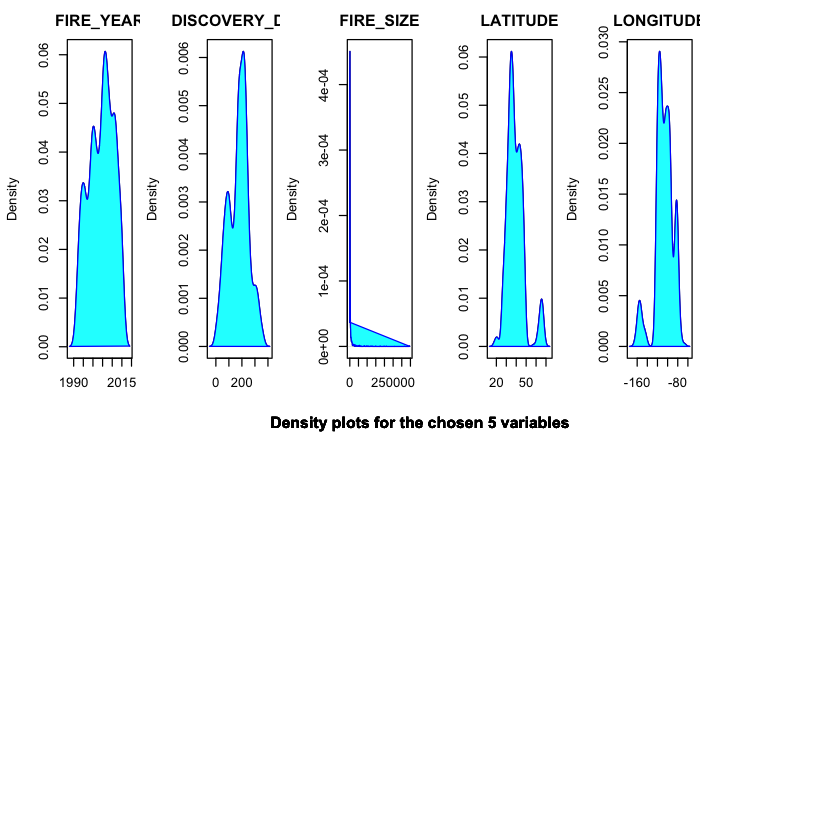

In [23]:
par(mfrow=c(2,6),mar=c(3.90, 4.25, 2.5, 0.5))
for (variables in 1:(dim(wildfires_300)[2]-1)){
  thisvar = wildfires_300[,variables]
  d <- density(thisvar)
  plot(d, main = names(wildfires_300[variables]),xlab="")
  polygon(d, col="cyan", border="blue")
  title("Density plots for the chosen 5 variables",line = -27, outer = TRUE)}

`FIRE_SIZE` shows a heavy right skew even after filtering out values smaller than 300 acres. However, this is an appropriate cut-off, as the data entries are now roughly 1300, which is already roughly 87% decrease.

### Temporal Pattern

In [52]:
wildfires_300 <- wildfires_300 %>% 
    mutate(FIRE_DATE = as.Date(paste(FIRE_YEAR, DISCOVERY_DOY, sep = "-"), format = "%Y-%j"),
          YEAR = year(FIRE_DATE),
          MONTH = month(FIRE_DATE))

#head(wildfires_300)

### Spatial Pattern

In [53]:
wildfires_300 <- wildfires_300 %>%
  mutate(
    lat_bin = floor(LATITUDE),
    lon_bin = floor(LONGITUDE),
    ym = YEAR * 100 + MONTH   # e.g., 201507
  )

head(wildfires_300)

,FIRE_YEAR,DISCOVERY_DOY,FIRE_SIZE,LATITUDE,LONGITUDE,STATE,FIRE_DATE,YEAR,MONTH,lat_bin,lon_bin,ym
,<int>,<int>,<dbl>,<dbl>,<dbl>,<fct>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2005,197,1300,33.93361,-111.3797,AZ,2005-07-16,2005,7,33,-112,200507
2,2005,198,495,33.86250,-111.1558,AZ,2005-07-17,2005,7,33,-112,200507
3,2005,219,800,48.83417,-115.1850,MT,2005-08-07,2005,8,48,-116,200508
4,2005,217,817,45.97667,-114.9600,ID,2005-08-05,2005,8,45,-115,200508
5,2005,224,600,45.74833,-115.1650,ID,2005-08-12,2005,8,45,-116,200508
6,2005,246,1132,43.82056,-115.8956,ID,2005-09-03,2005,9,43,-116,200509


We are creating a grid-month panel from the filtered fire data `wildfires_300`. Since we are retaining all notable fires with the size of >= 300 acres, `fire_this_month` should show all "1", meaning every entry of this panel has at least one confirmed fire at the mentioned size. 

In [57]:
grid_month_fire <- wildfires_300 |>
    mutate(
        lat_bin = lat_bin,
        lon_bin = lon_bin,
        ym = ym,
        fire_this_month = ifelse(DISCOVERY_DOY >= 1, 1, 0)
        )

grid_month_fire <- grid_month_fire |>
    select(lat_bin, lon_bin, ym, fire_this_month)

head(grid_month_fire)

,lat_bin,lon_bin,ym,fire_this_month
,<dbl>,<dbl>,<dbl>,<dbl>
1,33,-112,200507,1
2,33,-112,200507,1
3,48,-116,200508,1
4,45,-115,200508,1
5,45,-116,200508,1
6,43,-116,200509,1


Next, we are creating another grid-month panel, but it will conceptually be a "blank" panel regarding the info of fire occurence. This panel will have every possible combination of grid cell and month between the first date and last date of entries of the data set `wildfires`.

In [89]:
all_grids <- grid_month_fire %>% distinct(lat_bin, lon_bin)

# Generate a safe monthly sequence using actual dates
start_date <- ymd(paste0(min(grid_month_fire$ym) %/% 100, "-", min(grid_month_fire$ym) %% 100, "-01"))
end_date   <- ymd(paste0(max(grid_month_fire$ym) %/% 100, "-", max(grid_month_fire$ym) %% 100, "-01"))

all_months <- tibble(date = seq.Date(start_date, end_date, by = "month")) %>%
  mutate(year = year(date), month = month(date), ym = year * 100 + month) %>%
  select(ym, year, month)

panel <- crossing(all_grids, all_months)

panel_new <- left_join(panel, grid_month_fire, by = c("lat_bin", "lon_bin", "ym"))
panel_new <-unique(panel_new)

panel_new <- panel_new |>
   mutate(fire_this_month = ifelse(is.na(fire_this_month), 0, fire_this_month))

glimpse(panel_new)


Rows: 148,092
Columns: 6
$ lat_bin         <dbl> 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17…
$ lon_bin         <dbl> -67, -67, -67, -67, -67, -67, -67, -67, -67, -67, -67,…
$ ym              <dbl> 199201, 199202, 199203, 199204, 199205, 199206, 199207…
$ year            <dbl> 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, 1992, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ fire_this_month <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


### 2. Exploratory Data Analysis  

The purpose of this section is to build intuition about the data and to justify modeling decisions.

You may explore questions such as

- How does wildfire incidence vary across space?
- How strong is seasonality?
- How do predictors differ between fire and non-fire observations?
- Are there trends over time?


**Minimum required output:** The report should include at least **two** exploratory plots that demonstrate the spatial and temporal patterns of wildfires. Each plot should be accompanied by a brief interpretation.



### 3. Modeling

In this section, you will specify and justify the predictive models. You must fit at least **two** models.

1. **Baseline model.** A simple and interpretable model (e.g., logistic regression) that establishes a performance benchmark. Attend discussion session to get code for this baseline model!

2. **Model of your choice.** This is the model that you choose, after careful examination of the dataset. Ideally, your model should outperform the baseline model. 
   
**Minimum required output:** Description of both the baseline model and the model of your choice.


Baseline: linear regression
Model of choice: example such as non-linear from EDA


### 4. Model Fitting and Validation

This section evaluates how well the models fit historical data and how they generalize over time. You need to use a proper validation method that respect the temporal structure. In other words, the model should avoid data leakage such as predicting outcomes in the past using models trained by future data. 

The performance of the models should be evaluated by proper metrics. One required metric is the Area Under the ROC Curve (AUC). If AUC is not fully appropriate for your second model, you may include additional metrics, but AUC must still be reported for both models.


**Minimum required output:** You must include at least one diagnostic plot (e.g., training loss over iterations, cross-validated AUC over time). 


### 5. Summary

This section summarizes the main findings and contributions of your project. You should summarize the key insights obtained from the exploratory data analysis and explain what your predictive model is able to capture. The discussion should be written for a general audience, emphasizing interpretation and practical understanding rather than technical detail.

**Minimum required output:** Summary of EDA and model performance. 